# **Landslides triggered by Hurricane Helene in North Carolina**

```{image} ../thumbnails/USGS_logo.png
:alt: USGS logo
:width: 200px
```

---

### **Overview** 

Hurricane Helene was a Category 4 tropical cyclone that made landfall in September 2024. Different states across the United States suffered the impacts of this catastrophic hurricane. According to the USDA Risk Management Agency , Alabama, Florida, Georgia, Kentucky, North Carolina, Ohio, South Carolina, Tennessee, Virginia, and West Virginia were affected by Helene. 

This notebook analyzes the landslides triggered by Hurricane Helene in North Carolina. 
1. Load the USGS preliminary landslide inventory for Hurricane Helene.
2. Define the study domain over western North Carolina, including the Appalachian Mountains.
3. Plot the spatial distribution of landslides using Cartopy and Contextily basemaps.
4. Reference locations (Asheville and Sugar Grove) from helene_flooding.
5. Visualize landslides over a basemap to highlight the terrain influence. 

:::{note}
The landslide dataset was obtained from the [**United States Geological Survey Preliminary Landslide Inventory**](https://www.sciencebase.gov/catalog/item/674634a1d34e6d1dac3abddc).
:::

--- 

### **Imports** 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import contextily as ctx

---

### **Open dataset** 

In [2]:
csv_path = "HurricaneHelene_LS_Inventory.csv"
df = pd.read_csv(csv_path)

### **Landslides over North Carolina** 

This map shows the spatial distribution of landslides triggered by Hurricane Helene across North Carolina. This is a visualization that can be helpful to understand how the terrain influences mass movement.

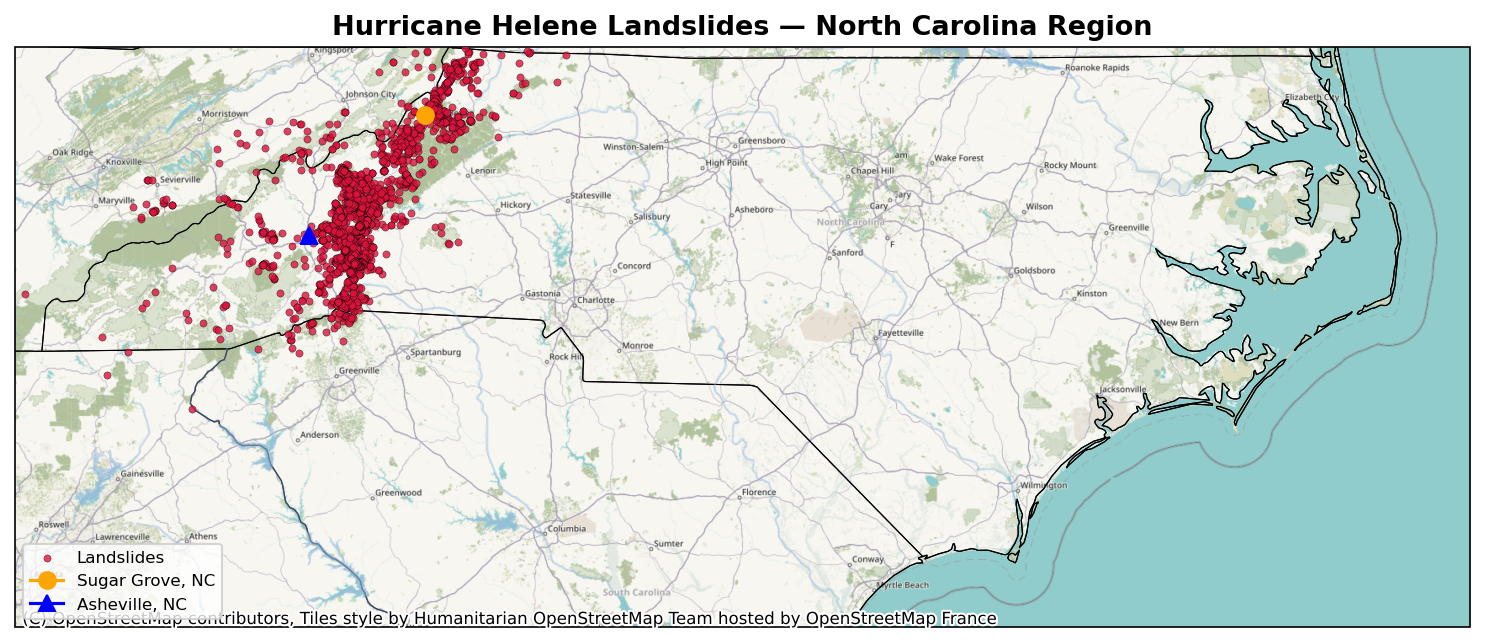

In [4]:
lon_col = "Longitude"
lat_col = "Latitude"

# North Carolina domain
latS, latN = 33.5, 36.6
lonW, lonE = -84.5, -75.0
res = "10m"

# Web Mercator for Contextily
proj = ccrs.epsg(3857)

fig = plt.figure(figsize=(10, 10), dpi=150)
ax = fig.add_subplot(1, 1, 1, projection=proj)

# Set map extent in lat/lon
ax.set_extent([lonW, lonE, latS, latN], crs=ccrs.PlateCarree())

# Cartopy Features
ax.add_feature(cfeature.COASTLINE.with_scale(res), linewidth=0.6)
ax.add_feature(cfeature.STATES.with_scale(res), linewidth=0.5)
ax.add_feature(cfeature.LAKES.with_scale(res), alpha=0.5)
ax.add_feature(cfeature.RIVERS.with_scale(res), alpha=0.4)

# Locations (stations)
lat_wat, lon_wat = 36.2391667, -81.8222222   # Sugar Grove / Watauga River
lat_ash, lon_ash = 35.608889,  -82.578056    # Asheville

# Plot landslides (df must contain "Latitude" and "Longitude")
ax.scatter(df[lon_col], df[lat_col], s=12, c="crimson", alpha=0.8, edgecolor="k", linewidth=0.2, transform=ccrs.PlateCarree(), zorder=3, label="Landslides")

# Plot stations
ax.plot(lon_wat, lat_wat, marker="o", color="orange", markersize=8, transform=ccrs.PlateCarree(), zorder=5, label="Sugar Grove, NC")

ax.plot(lon_ash, lat_ash, marker="^", color="blue", markersize=8, transform=ccrs.PlateCarree(), zorder=5, label="Asheville, NC")

# Add Contextily basemap
ctx.add_basemap(ax, zoom=8, crs="EPSG:3857")

# Grid and Title
ax.grid(True, linestyle=":", alpha=0.5)
ax.set_title("Hurricane Helene Landslides — North Carolina Region", fontweight="bold", fontsize=13)

ax.legend(loc="lower left", fontsize=8, frameon=True)

plt.tight_layout()
plt.show()